Total valid inventory points: 137
Training set size (70%): 95
Testing set size (30%): 42
Flood distribution in test set: [22 20]


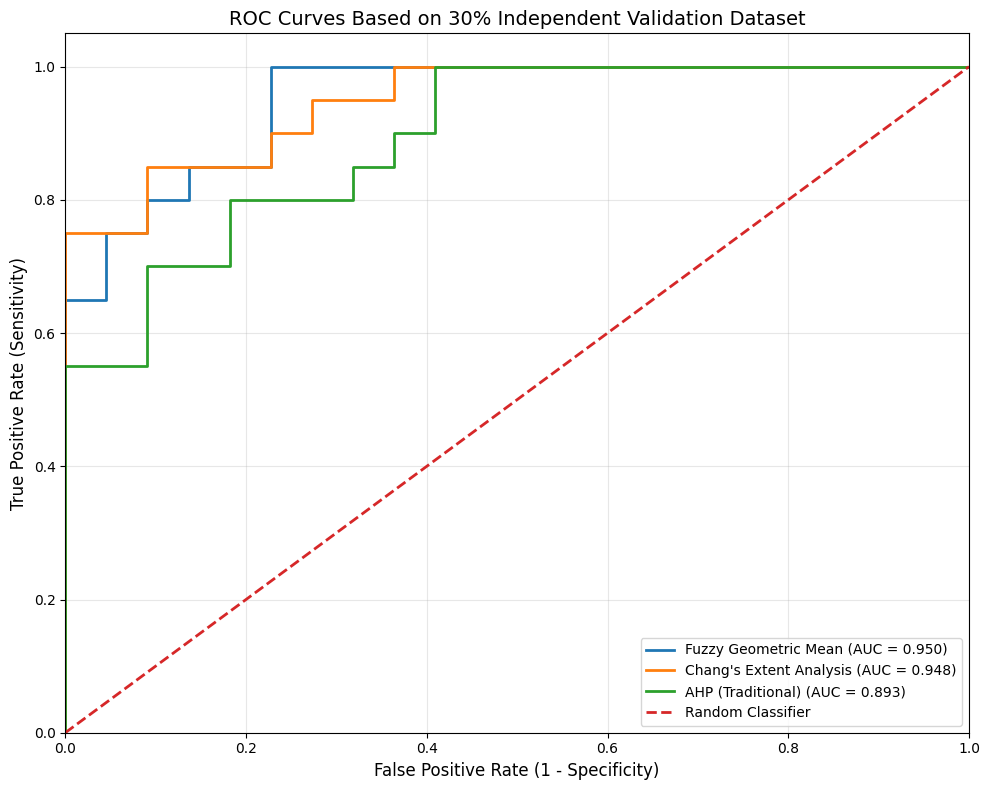


Validation Results
              Method/Model  Optimal Threshold (70% Training)  \
0     Fuzzy Geometric Mean                            0.0859   
1  Chang's Extent Analysis                            0.0864   
2        AHP (Traditional)                            2.9860   

   AUC (30% Validation)  Accuracy  Precision  Recall  F1-Score  
0                0.9500    0.8571     0.8500    0.85    0.8500  
1                0.9477    0.8333     0.8095    0.85    0.8293  
2                0.8932    0.7619     0.6923    0.90    0.7826  

Results saved successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Load data
# --------------------------------------------------
df_fgm = pd.read_csv('Extract_FGM_FAHP.csv')
df_few = pd.read_csv('Extract_FEW_FAHP.csv')
df_final = pd.read_csv('Final_Point.csv')

# --------------------------------------------------
# Retain only inventory points that contain valid
# raster values in all three susceptibility maps
# (FGM, CEA, and AHP)
# --------------------------------------------------
common_valid_indices = (
    set(df_fgm.dropna(subset=['RASTERVALU'])['system_index'])
    & set(df_few.dropna(subset=['RASTERVALU'])['system_index'])
    & set(df_final.dropna(subset=['RASTERVALU'])['system_index'])
)

df_fgm_filtered = (
    df_fgm[df_fgm['system_index'].isin(common_valid_indices)]
    .sort_values('system_index')
    .reset_index(drop=True)
)

df_few_filtered = (
    df_few[df_few['system_index'].isin(common_valid_indices)]
    .sort_values('system_index')
    .reset_index(drop=True)
)

df_ahp_filtered = (
    df_final[df_final['system_index'].isin(common_valid_indices)]
    .sort_values('system_index')
    .reset_index(drop=True)
)

print(f"Total valid inventory points: {len(df_fgm_filtered)}")

# --------------------------------------------------
# Create a stratified random split
# 70% Training (Calibration)
# 30% Testing (Independent Validation)
# Flood/non-flood proportions are preserved
# --------------------------------------------------
indices = np.arange(len(df_fgm_filtered))
y_labels = df_fgm_filtered['flood'].values

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.30,      # 30% validation
    random_state=42,
    stratify=y_labels
)

print(f"Training set size (70%): {len(train_idx)}")
print(f"Testing set size (30%): {len(test_idx)}")
print(f"Flood distribution in test set: {np.bincount(y_labels[test_idx])}")

# --------------------------------------------------
# Extract validation subset (30%)
# --------------------------------------------------
df_fgm_test = df_fgm_filtered.iloc[test_idx]
df_few_test = df_few_filtered.iloc[test_idx]
df_ahp_test = df_ahp_filtered.iloc[test_idx]

# --------------------------------------------------
# Extract calibration subset (70%)
# Used to determine optimal threshold
# --------------------------------------------------
df_fgm_train = df_fgm_filtered.iloc[train_idx]
df_few_train = df_few_filtered.iloc[train_idx]
df_ahp_train = df_ahp_filtered.iloc[train_idx]

# --------------------------------------------------
# Function to calculate ROC-AUC and classification
# metrics using threshold derived from training data
# --------------------------------------------------
def calculate_metrics_split(
    df_train,
    df_test,
    label_col='flood',
    score_col='RASTERVALU'
):
    
    # Determine optimal threshold from training data
    # using Youden's J statistic
    fpr_tr, tpr_tr, thresholds_tr = roc_curve(
        df_train[label_col],
        df_train[score_col]
    )

    j_scores = tpr_tr - fpr_tr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds_tr[best_idx]

    # ROC analysis on independent test dataset
    y_true = df_test[label_col]
    y_scores = df_test[score_col]

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Classification metrics
    y_pred = (y_scores >= best_threshold).astype(int)

    return {
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'acc': accuracy_score(y_true, y_pred),
        'prec': precision_score(y_true, y_pred, zero_division=0),
        'rec': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'threshold': best_threshold
    }

# --------------------------------------------------
# Calculate metrics for all three models
# --------------------------------------------------
results_fgm = calculate_metrics_split(
    df_fgm_train,
    df_fgm_test
)

results_few = calculate_metrics_split(
    df_few_train,
    df_few_test
)

results_ahp = calculate_metrics_split(
    df_ahp_train,
    df_ahp_test
)

# --------------------------------------------------
# Plot ROC Curves
# --------------------------------------------------
plt.figure(figsize=(10, 8))

plt.plot(
    results_fgm['fpr'],
    results_fgm['tpr'],
    lw=2,
    label=f'Fuzzy Geometric Mean (AUC = {results_fgm["auc"]:.3f})'
)

plt.plot(
    results_few['fpr'],
    results_few['tpr'],
    lw=2,
    label=f'Chang\'s Extent Analysis (AUC = {results_few["auc"]:.3f})'
)

plt.plot(
    results_ahp['fpr'],
    results_ahp['tpr'],
    lw=2,
    label=f'AHP (Traditional) (AUC = {results_ahp["auc"]:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    lw=2,
    label='Random Classifier'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)

plt.title(
    'ROC Curves Based on 30% Independent Validation Dataset',
    fontsize=14
)

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    'roc_curves_70_train_30_test.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# --------------------------------------------------
# Summary Table
# --------------------------------------------------
summary_df = pd.DataFrame({
    'Method/Model': [
        'Fuzzy Geometric Mean',
        'Chang\'s Extent Analysis',
        'AHP (Traditional)'
    ],
    'Optimal Threshold (70% Training)': [
        results_fgm['threshold'],
        results_few['threshold'],
        results_ahp['threshold']
    ],
    'AUC (30% Validation)': [
        results_fgm['auc'],
        results_few['auc'],
        results_ahp['auc']
    ],
    'Accuracy': [
        results_fgm['acc'],
        results_few['acc'],
        results_ahp['acc']
    ],
    'Precision': [
        results_fgm['prec'],
        results_few['prec'],
        results_ahp['prec']
    ],
    'Recall': [
        results_fgm['rec'],
        results_few['rec'],
        results_ahp['rec']
    ],
    'F1-Score': [
        results_fgm['f1'],
        results_few['f1'],
        results_ahp['f1']
    ]
})

# Round values for cleaner output
summary_df.iloc[:, 1:] = summary_df.iloc[:, 1:].round(4)

print("\nValidation Results")
print(summary_df)

summary_df.to_csv(
    'validation_metrics_70_train_30_test.csv',
    index=False
)

print("\nResults saved successfully.")

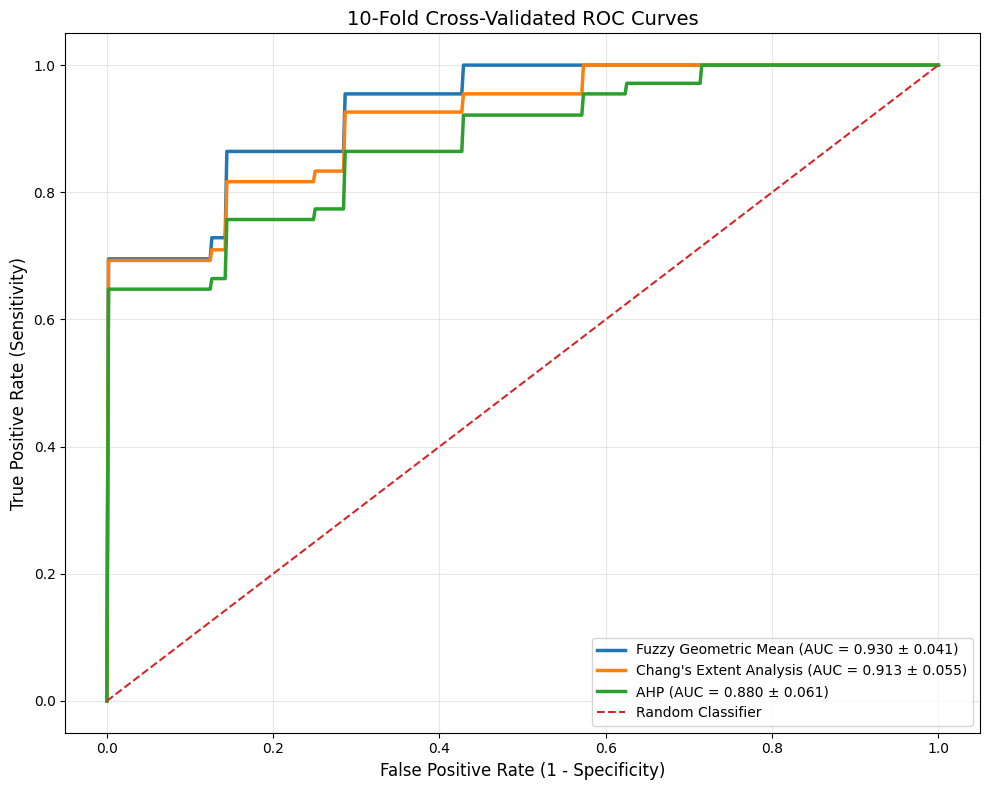

                    Method  Mean AUC  AUC Std. Dev.
0     Fuzzy Geometric Mean    0.9305         0.0414
1  Chang's Extent Analysis    0.9131         0.0553
2                      AHP    0.8796         0.0614


In [3]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Cross-validated ROC function
# --------------------------------------------------
def cross_validated_roc(df, label_col='flood', score_col='RASTERVALU'):

    X = df[score_col].values
    y = df[label_col].values

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    mean_fpr = np.linspace(0, 1, 500)

    tprs = []
    aucs = []

    for train_idx, test_idx in cv.split(X, y):

        y_test = y[test_idx]
        score_test = X[test_idx]

        fpr, tpr, _ = roc_curve(y_test, score_test)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    return mean_fpr, mean_tpr, mean_auc, std_auc

# --------------------------------------------------
# Compute cross-validated ROC curves
# --------------------------------------------------
fgm_fpr, fgm_tpr, fgm_auc, fgm_std = cross_validated_roc(df_fgm_filtered)

few_fpr, few_tpr, few_auc, few_std = cross_validated_roc(df_few_filtered)

ahp_fpr, ahp_tpr, ahp_auc, ahp_std = cross_validated_roc(df_ahp_filtered)

# --------------------------------------------------
# Plot mean ROC curves
# --------------------------------------------------
plt.figure(figsize=(10, 8))

plt.plot(
    fgm_fpr,
    fgm_tpr,
    linewidth=2.5,
    label=f'Fuzzy Geometric Mean (AUC = {fgm_auc:.3f} ± {fgm_std:.3f})'
)

plt.plot(
    few_fpr,
    few_tpr,
    linewidth=2.5,
    label=f"Chang's Extent Analysis (AUC = {few_auc:.3f} ± {few_std:.3f})"
)

plt.plot(
    ahp_fpr,
    ahp_tpr,
    linewidth=2.5,
    label=f'AHP (AUC = {ahp_auc:.3f} ± {ahp_std:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random Classifier'
)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)

plt.title(
    '10-Fold Cross-Validated ROC Curves',
    fontsize=14
)

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'ROC_10Fold_CrossValidation.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# --------------------------------------------------
# Summary table
# --------------------------------------------------
summary_df = pd.DataFrame({
    'Method': [
        'Fuzzy Geometric Mean',
        "Chang's Extent Analysis",
        'AHP'
    ],
    'Mean AUC': [
        fgm_auc,
        few_auc,
        ahp_auc
    ],
    'AUC Std. Dev.': [
        fgm_std,
        few_std,
        ahp_std
    ]
})

print(summary_df.round(4))

summary_df.to_csv(
    '10Fold_CV_AUC_Results.csv',
    index=False
)

In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def mean_roc_curve(df, label_col='flood', score_col='RASTERVALU'):

    X = df[score_col].values
    y = df[label_col].values

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    mean_fpr = np.linspace(0, 1, 500)

    tprs = []
    aucs = []

    for train_idx, test_idx in cv.split(X, y):

        y_test = y[test_idx]
        score_test = X[test_idx]

        fpr, tpr, _ = roc_curve(y_test, score_test)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0

        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1

    mean_auc = np.mean(aucs)

    return mean_fpr, mean_tpr, mean_auc

# Calculate mean ROC curves
dataframes = {
    'Fuzzy Geometric Mean': globals().get('df_fgm_filtered'),
    "Chang's Extent Analysis": globals().get('df_few_filtered'),
    'AHP': globals().get('df_ahp_filtered')
}

roc_results = {}
for method_name, df in dataframes.items():
    if df is not None:
        roc_results[method_name] = mean_roc_curve(df)

if not roc_results:
    raise ValueError(
        "No filtered dataframes were found. Expected one or more of: "
        "df_fgm_filtered, df_few_filtered, df_ahp_filtered."
    )

# Plot
plt.figure(figsize=(10,8))

for method_name, (fpr, tpr, mean_auc) in roc_results.items():
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f'{method_name} (AUC = {mean_auc:.3f})'
    )

plt.plot(
    [0,1],
    [0,1],
    'k--',
    linewidth=1.5,
    label='Random Classifier'
)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)

plt.title(
    'ROC-AUC',
    fontsize=14
)

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'Mean_ROC.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Method': list(roc_results.keys()),
    'Mean AUC': [result[2] for result in roc_results.values()]
})

print(summary_df.round(4))
summary_df.to_csv('Mean_AUC.csv', index=False)

NameError: name 'df_fgm_filtered' is not defined